<a href="https://colab.research.google.com/github/MavrinIlua/Mavrin-Ilua-Borisovich_ResumeAndPortfolio/blob/main/%D0%9C%D0%B0%D0%B2%D1%80%D0%B8%D0%BD%20%D0%98.%D0%91_%D0%9A%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D1%8F_%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

КЛАССИФИКАЦИЯ

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import pydotplus
from IPython.display import Image

# Данные
data = pd.DataFrame({
    'Возраст': [17, 64, 18, 20, 38, 49, 55, 25, 29, 31, 33],
    'Стаж работы': [0, 40, 0, 1, 7, 29, 30, 5, 1, 10, 11],
    'Балл': [25, 80, 22, 36, 37, 59, 74, 70, 33, 100, 88],
    'Выполнение проекта': [1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1]
})

In [ ]:
# Признаки и целевая переменная
X = data[['Возраст', 'Стаж работы', 'Балл']]  # Признаки
y = data['Выполнение проекта']  # Целевая переменная

# Создание и обучение модели дерева решений
# Используется класс fit из библиотеки scikit-learn для создания дерева решений для задачи классификации
#Установка random_state в фиксированное значение (например, 17) обеспечивает один и тотже результат при повторных запусках

model = DecisionTreeClassifier(random_state=17)
model.fit(X, y)

# Оценка важности признаков
importances = model.feature_importances_

# Вывод важности признаков
for feature, importance in zip(X.columns, importances):
    print(f"{feature}: {importance:.4f}")

Возраст: 0.5198
Стаж работы: 0.0000
Балл: 0.4802


In [ ]:
# Модель дерева решений

# Выбор признаков и целевой переменной
X = data[['Возраст', 'Балл']]  # Признаки
y = data['Выполнение проекта']  # Целевая переменная

# Обучение модели
#используется класс fit из библиотеки scikit-learn для создания деревf решений для задачb классификации
#Установка random_state в фиксированное значение (например, 17) обеспечивает один и тотже результат при повторных запусках
# Модель дерева решений
model = DecisionTreeClassifier(random_state=17)

#age_sal_tree.fit(X_train, y_train), где X_train — это матрица признаков (например, возраст и зарплата), а y_train — целевая переменная, то что нужно предсказать
model.fit(X, y)

DecisionTreeClassifier(random_state=17)

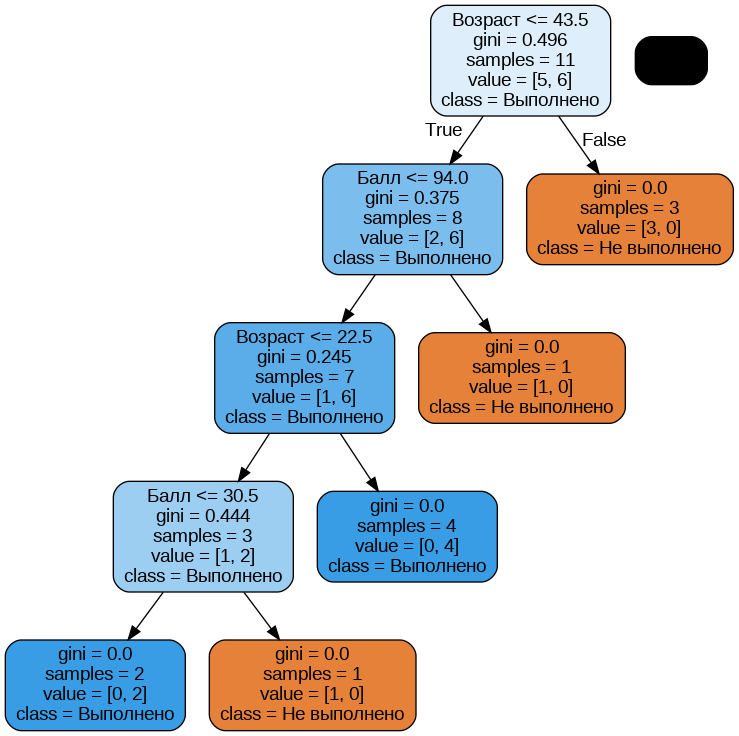

In [ ]:
# Визуализация дерева
dot_data = tree.export_graphviz(model,
                                feature_names=['Возраст', 'Балл'],
                                class_names=['Не выполнено', 'Выполнено'],
                                filled=True,
                                rounded=True)

# Создание графа
graph = pydotplus.graph_from_dot_data(dot_data)

# Отображаем изображение дерева
Image(graph.create_png())

# Либо сохраняем файл:
# graph.write_png("decision_tree.png")


Коэффициент Джини (Gini coefficient) — метрика качества

In [ ]:
# Предсказание для всех студентов на тех же данных (для демонстрации)
y_pred = model.predict(X)

# Добавляем предсказания в исходный датафрейм
data['Предсказанное выполнение проекта'] = y_pred

# Разделение студентов на две группы
group_1 = data[data['Предсказанное выполнение проекта'] == 1]
group_2 = data[data['Предсказанное выполнение проекта'] == 0]

print("\nГруппа 1 (предсказано выполнение проекта):")
print(group_1)

print("\nГруппа 2 (предсказано невыполнение проекта):")
print(group_2)


Группа 1 (предсказано выполнение проекта):
    Возраст  Стаж работы  Балл  Выполнение проекта  \
0        17            0    25                   1   
2        18            0    22                   1   
4        38            7    37                   1   
7        25            5    70                   1   
8        29            1    33                   1   
10       33           11    88                   1   

    Предсказанное выполнение проекта  
0                                  1  
2                                  1  
4                                  1  
7                                  1  
8                                  1  
10                                 1  

Группа 2 (предсказано невыполнение проекта):
   Возраст  Стаж работы  Балл  Выполнение проекта  \
1       64           40    80                   0   
3       20            1    36                   0   
5       49           29    59                   0   
6       55           30    74                 

In [ ]:
# Вывод отчета о классификации
# метрики точность (precision), полнота (recall), F1-мера (F1-score) и поддержка (support)
from sklearn.metrics import classification_report
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         6

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



In [ ]:
new_student = [[30, 50]]  # Возраст и Балл нового студента
prediction = model.predict(new_student)
print(f'Вероятность выполнения проекта новым студентом: {prediction[0]}')

Вероятность выполнения проекта новым студентом: 1


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


В данном случае модель идеально справилась с предсказаниями (все метрики равны 1.0), потому что она обучалась и тестировалась на одних и тех же данных. Это может указывать на переобучение.

Для более реалистичной оценки нужно разделить данные на обучающую и тестовую выборки (например, с помощью train_test_split).

МОДЕЛЬ ДЕРЕВА РЕШЕНИЙ

In [ ]:
# Выбор признаков и целевой переменной
X = data[['Возраст', 'Балл']]  # Признаки
y = data['Выполнение проекта']  # Целевая переменная

# Обучение модели
#используется класс fit из библиотеки scikit-learn для создания деревf решений для задачb классификации
#Установка random_state в фиксированное значение (например, 17) обеспечивает один и тотже результат при повторных запусках
# Модель дерева решений
model = DecisionTreeClassifier(random_state=17)

#age_sal_tree.fit(X_train, y_train), где X_train — это матрица признаков (например, возраст и зарплата), а y_train — целевая переменная, то что нужно предсказать
model.fit(X, y)

DecisionTreeClassifier(random_state=17)

In [ ]:
from sklearn.model_selection import train_test_split

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=17)

# Обучение модели
model.fit(X_train, y_train)

# Предсказание на тестовых данных
y_pred = model.predict(X_test)

# Отчет о классификации
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.75      1.00      0.86         3

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


СЛУЧАЙНЫЙ ЛЕС


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Загрузка данных
X = data[['Возраст', 'Балл', 'Стаж работы']]  # Признаки
y = data['Выполнение проекта']  # Целевая переменная

# Разделение данных на тренировочные и тестовые наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создание модели Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Обучение модели
rf_model.fit(X_train, y_train)

# Получение оценок важности признаков
importance = rf_model.feature_importances_

# Печать важности признаков
for i in range(len(importance)):
    print(f"{X.columns[i]}: {importance[i]*100:.2f}%")

Возраст: 38.28%
Балл: 34.88%
Стаж работы: 26.84%


In [ ]:
new_student = [[87, 90, 40]]  # Возраст и Балл нового студента
prediction = rf_model.predict(new_student)
print(f'Вероятность выполнения проекта новым студентом: {prediction[0]}')

Вероятность выполнения проекта новым студентом: 0


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


КЛАСТЕРИЗАЦИЯ

Применение алгоритма K-means

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [ ]:
# Выбираем признаки для кластеризации
features = ['Возраст', 'Стаж работы', 'Балл']
X = data[features]

# Применяем алгоритм K-means с числом кластеров равным 3
kmeans = KMeans(n_clusters=3, random_state=17)
kmeans.fit(X)

# Добавляем метки кластеров к данным
data['Cluster'] = kmeans.labels_

In [ ]:
# Распечатываем данные с добавленными метками кластеров
print(data)

In [ ]:
# Графическое представление кластеров
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(data['Возраст'], data['Балл'], c=data['Cluster'], cmap='viridis')
ax.set_xlabel('Возраст')
ax.set_ylabel('Балл')
ax.set_title('Распределение студентов по кластерам')
plt.show()

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Выбираем признаки для кластеризации
features = ['Возраст', 'Стаж работы', 'Балл']
X = data[features]

# Применяем алгоритм K-means с числом кластеров равным 3
kmeans = KMeans(n_clusters=3, random_state=17)
kmeans.fit(X)

# Добавляем метки кластеров к данным
data['Cluster'] = kmeans.labels_

# Визуализация трехмерного графика с кластерами
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Рисуем точки, раскрашивая их по кластерам
ax.scatter(
    data['Возраст'],
    data['Стаж работы'],
    data['Балл'],
    c=data['Cluster'],
    cmap='viridis',
    s=60  # Размер точек
)

# Названия осей
ax.set_xlabel('Возраст')
ax.set_ylabel('Стаж работы')
ax.set_zlabel('Балл')

# Заголовок графика
ax.set_title('Распределение студентов по кластерам')

# Показываем график
plt.show()

Работа с набором данных

In [ ]:
import pandas as pd

# Загрузите файл
df = pd.read_csv('/content/StudentsPerformance.csv')

# Выведите первые строки
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('/content/StudentsPerformance.csv')

# Определим категориальные и числовые признаки
categorical_features = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
numeric_features = ['math score', 'reading score', 'writing score']

# Преобразуем категориальные признаки в числовые с помощью One-Hot Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),  # Нормализация числовых признаков
        ('cat', OneHotEncoder(), categorical_features)  # One-Hot Encoding для категориальных признаков
    ])

# Создаем пайплайн для предобработки и кластеризации
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('cluster', KMeans(n_clusters=3, random_state=17))  # Кластеризация с 3 кластерами
])

# Применяем пайплайн к данным
df['cluster'] = pipeline.fit_predict(df)

# Визуализация результатов
plt.figure(figsize=(10, 6))
sns.scatterplot(x='math score', y='reading score', hue='cluster', data=df, palette='viridis')
plt.title('Комплексная кластеризация студентов')
plt.xlabel('Math Score')
plt.ylabel('Reading Score')
plt.show()

# Анализ кластеров: только числовые признаки
cluster_analysis = df.groupby('cluster')[numeric_features].mean()
print(cluster_analysis)

РЕШЕНИЕ ЗАДАЧИ НА ПОИСК ЦЕНТРОИДОВ БЕЗ БИБЛИОТЕКИ МАШИННОГО ОБУЧЕНИЯ

In [ ]:
# Импортируем функцию dist из модуля math для вычисления расстояния между точками
from math import dist

# Базовый путь к файлам (пустой, значит файлы лежат в той же папке)
base = ''

# Список файлов с данными для обработки
files = ['27_A.txt', '27_B.txt']

# Обрабатываем оба файла по очереди (task = 0 для 27_A.txt, task = 1 для 27_B.txt)
for task in (0, 1):
    # Параметр eps (максимальное расстояние между точками для включения в один кластер)
    eps = 1.6

    # Открываем файл и считываем данные
    fd = open(base + files[task])
    fd.readline()  # Пропускаем первую строку (заголовок, если есть)

    # Преобразуем строки файла в список точек (каждая строка -> кортеж (x, y))
    # Заменяем запятые на точки для корректного преобразования в float
    data = [tuple(map(float, line.replace(',', '.').split())) for line in fd]

    # Список для хранения кластеров
    clusters = []

    # Пока есть точки для обработки
    while data:
        # Берем последнюю точку из data и создаем новый кластер
        clusters.append([data.pop()])

        # Для каждой точки в текущем кластере ищем соседей в радиусе eps
        for p in clusters[-1]:
            # Находим все точки из data, которые находятся на расстоянии < eps от p
            neigh = [pt for pt in data if dist(p, pt) < eps]

            # Добавляем найденных соседей в текущий кластер
            clusters[-1] += neigh

            # Удаляем добавленные точки из data, чтобы они не попали в другие кластеры
            for pt in neigh:
                data.remove(pt)

    # Теперь ищем "центры" кластеров — точки с минимальной суммой расстояний до остальных
    centers = []
    for cl in clusters:
        d_min = float('inf')  # Минимальная сумма расстояний (изначально бесконечность)
        c = None  # Точка-центр (пока не определена)

        # Перебираем все точки кластера и ищем ту, у которой сумма расстояний до остальных минимальна
        for p in cl:
            d = sum(dist(p, pt) for pt in cl)  # Сумма расстояний от p до всех точек кластера
            if d < d_min:  # Если найдена точка с меньшей суммой
                d_min = d
                c = p  # Запоминаем её как новый центр

        centers.append(c)  # Добавляем найденный центр в список

    # Вычисляем среднее арифметическое координат всех центров
    px = sum(p[0] for p in centers) / len(centers)  # Среднее по X
    py = sum(p[1] for p in centers) / len(centers)  # Среднее по Y

    # Выводим результат в виде целых чисел (умножаем на 10 000 и берем модуль)
    print(int(abs(px) * 10000), int(abs(py) * 10000))

28603 10294
61260 11206


Алгоритм кластеризации похож на упрощенный DBSCAN, где:

eps — радиус поиска соседних точек.

Кластер формируется вокруг начальной точки, пока есть соседи в пределах eps.

Поиск центра кластера — это не просто среднее арифметическое, а точка с минимальной суммой расстояний до остальных (медианный центр).

Финальный результат — среднее от всех центров кластеров, преобразованное в целое число